<a href="https://colab.research.google.com/github/GSK7625/DO-AN-THI-GIAC-MAY-TINH/blob/kien/EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
!pip install -qU kaggle

In [10]:
!pip install -qU kagglehub

In [8]:
import kagglehub

path = kagglehub.dataset_download("faihajalamtopu/ucf-qnrf")

print("Path to dataset files:", path)

100%|██████████| 4.24G/4.24G [03:08<00:00, 24.1MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/faihajalamtopu/ucf-qnrf/versions/1


In [11]:
import kagglehub

path = kagglehub.dataset_download("tthien/shanghaitech")

print("Path to dataset files:", path)

100%|██████████| 333M/333M [00:18<00:00, 18.6MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/tthien/shanghaitech/versions/1


=== SHANGHAITECH PART B ===
Train images : 400
Test images  : 316
Min count    : 9
Max count    : 576
Avg count    : 123.3
Median count : 95.5


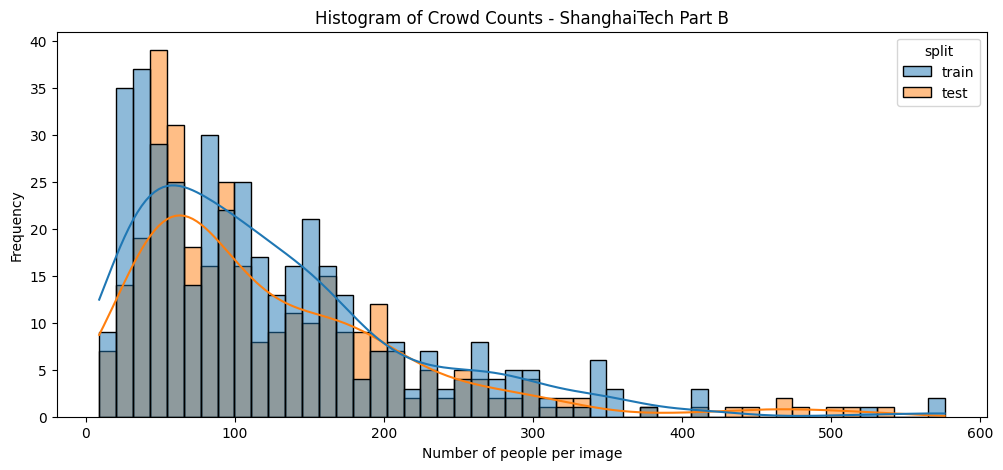

In [21]:
import scipy.io as sio
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import pandas as pd
import os

def get_count(mat_path):
    mat = sio.loadmat(mat_path)
    if 'image_info' in mat:
        return mat['image_info'][0][0][0][0][1][0][0]
    return 0

# Create reports directory
os.makedirs("reports", exist_ok=True)

train_gt = list(Path("/root/.cache/kagglehub/datasets/tthien/shanghaitech/versions/1/ShanghaiTech/part_B/train_data/ground-truth").glob("*.mat"))
test_gt = list(Path("/root/.cache/kagglehub/datasets/tthien/shanghaitech/versions/1/ShanghaiTech/part_B/test_data/ground-truth").glob("*.mat"))

counts_train = [get_count(p) for p in train_gt]
counts_test = [get_count(p) for p in test_gt]

# Create DataFrame
df = pd.DataFrame({
    "dataset": ["ShanghaiTech B Train"]*len(counts_train) + ["ShanghaiTech B Test"]*len(counts_test),
    "count": counts_train + counts_test,
    "split": ["train"]*len(counts_train) + ["test"]*len(counts_test)
})

# Summary report
print("=== SHANGHAITECH PART B ===")
print(f"Train images : {len(counts_train)}")
print(f"Test images  : {len(counts_test)}")
print(f"Min count    : {df['count'].min()}")
print(f"Max count    : {df['count'].max()}")
print(f"Avg count    : {df['count'].mean():.1f}")
print(f"Median count : {df['count'].median():.1f}")

plt.figure(figsize=(12, 5))
sns.histplot(data=df, x="count", hue="split", bins=50, kde=True)
plt.title("Histogram of Crowd Counts - ShanghaiTech Part B")
plt.xlabel("Number of people per image")
plt.ylabel("Frequency")
plt.savefig("reports/shanghaitech_histogram.png", dpi=300, bbox_inches='tight')
plt.show()

=== SHANGHAITECH PART A ===
Train images : 300
Test images  : 182
Min count    : 33
Max count    : 3138
Avg count    : 500.6
Median count : 359.0


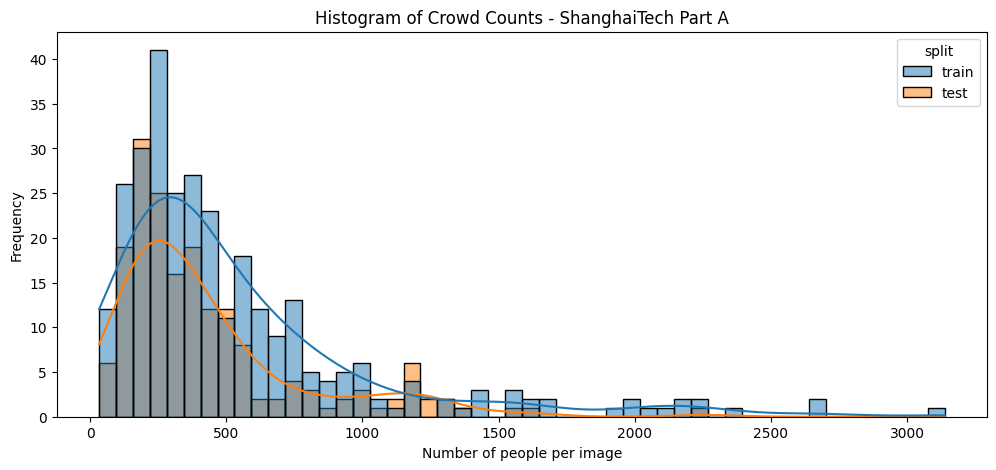

In [25]:
import scipy.io as sio
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import pandas as pd
import os

def get_count(mat_path):
    mat = sio.loadmat(mat_path)
    if 'image_info' in mat:
        return mat['image_info'][0][0][0][0][1][0][0]
    return 0

# Create reports directory
os.makedirs("reports", exist_ok=True)

train_gt = list(Path("/root/.cache/kagglehub/datasets/tthien/shanghaitech/versions/1/ShanghaiTech/part_A/train_data/ground-truth").glob("*.mat"))
test_gt = list(Path("/root/.cache/kagglehub/datasets/tthien/shanghaitech/versions/1/ShanghaiTech/part_A/test_data/ground-truth").glob("*.mat"))

counts_train = [get_count(p) for p in train_gt]
counts_test = [get_count(p) for p in test_gt]

# Create DataFrame
df = pd.DataFrame({
    "dataset": ["ShanghaiTech A Train"]*len(counts_train) + ["ShanghaiTech A Test"]*len(counts_test),
    "count": counts_train + counts_test,
    "split": ["train"]*len(counts_train) + ["test"]*len(counts_test)
})

# Summary report
print("=== SHANGHAITECH PART A ===")
print(f"Train images : {len(counts_train)}")
print(f"Test images  : {len(counts_test)}")
print(f"Min count    : {df['count'].min()}")
print(f"Max count    : {df['count'].max()}")
print(f"Avg count    : {df['count'].mean():.1f}")
print(f"Median count : {df['count'].median():.1f}")

plt.figure(figsize=(12, 5))
sns.histplot(data=df, x="count", hue="split", bins=50, kde=True)
plt.title("Histogram of Crowd Counts - ShanghaiTech Part A")
plt.xlabel("Number of people per image")
plt.ylabel("Frequency")
plt.savefig("reports/shanghaitech_histogram.png", dpi=300, bbox_inches='tight')
plt.show()

=== UCF-QNRF DATASET ===
Train images : 1201
Test images  : 334
Min count    : 49
Max count    : 12865
Avg count    : 815.4
Median count : 425.0


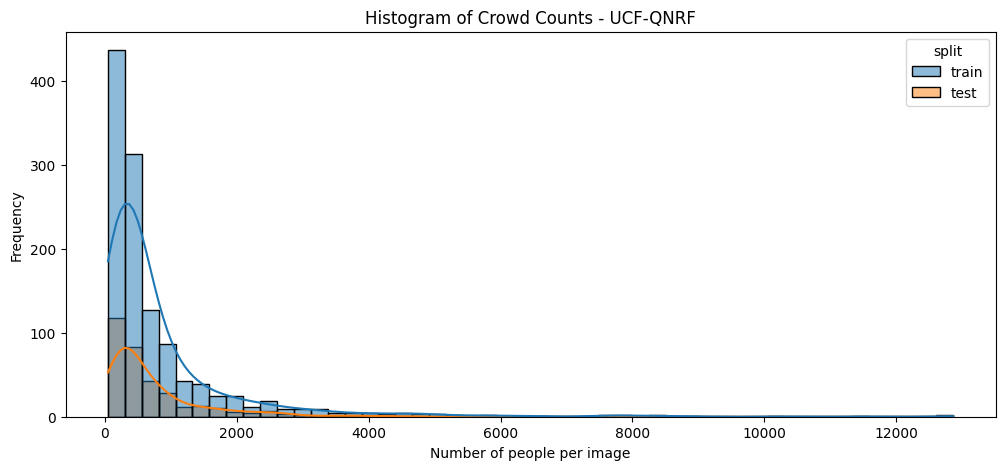

In [24]:
import scipy.io as sio
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import pandas as pd
import os

def get_count(mat_path):
    mat = sio.loadmat(mat_path)
    # Check for UCF-QNRF format
    if 'annPoints' in mat:
        return len(mat['annPoints'])
    # Check for ShanghaiTech format
    if 'image_info' in mat:
        return mat['image_info'][0][0][0][0][1][0][0]
    return 0

# Create reports directory
os.makedirs("reports", exist_ok=True)

# UCF-QNRF paths
train_gt = list(Path("/root/.cache/kagglehub/datasets/faihajalamtopu/ucf-qnrf/versions/1/UCF-QNRF_ECCV18/Train").glob("*.mat"))
test_gt = list(Path("/root/.cache/kagglehub/datasets/faihajalamtopu/ucf-qnrf/versions/1/UCF-QNRF_ECCV18/Test").glob("*.mat"))

counts_train = [get_count(p) for p in train_gt]
counts_test = [get_count(p) for p in test_gt]

# Create DataFrame
df = pd.DataFrame({
    "dataset": ["UCF-QNRF Train"]*len(counts_train) + ["UCF-QNRF Test"]*len(counts_test),
    "count": counts_train + counts_test,
    "split": ["train"]*len(counts_train) + ["test"]*len(counts_test)
})

# Summary report
print("=== UCF-QNRF DATASET ===")
print(f"Train images : {len(counts_train)}")
print(f"Test images  : {len(counts_test)}")
print(f"Min count    : {df['count'].min()}")
print(f"Max count    : {df['count'].max()}")
print(f"Avg count    : {df['count'].mean():.1f}")
print(f"Median count : {df['count'].median():.1f}")

plt.figure(figsize=(12, 5))
sns.histplot(data=df, x="count", hue="split", bins=50, kde=True)
plt.title("Histogram of Crowd Counts - UCF-QNRF")
plt.xlabel("Number of people per image")
plt.ylabel("Frequency")
plt.savefig("reports/ucf_qnrf_histogram.png", dpi=300, bbox_inches='tight')
plt.show()